In [1]:
%pip install opencv-python scipy

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
    --------------------------------------- 0.8/40.2 MB 4.5 MB/s eta 0:00:09
   - -------------------------------------- 1.8/40.2 MB 4.6 MB/s eta 0:00:09
   -- ------------------------------------- 2.9/40.2 MB 4.6 MB/s eta 0:00:09
   --- ------------------------------------ 3.7/40.2 MB 4.6 MB/s eta 0:00:08
   ---- ----------------------------------- 4.7/40.2 MB 4.6 MB/s eta 0:00:08
   ----- ---------------------------------- 5.5/40.2 MB 4.6 MB/s eta 0:00:08
   ------ --------------------------------- 6.6/40.2 MB 4.6 MB/s eta 0:00:08
   ------- -------------------------------- 7.6/40.2 MB 4.6 MB/s eta 0:00:08
   -------- ------------------------------- 8.4/40.2 MB 4.6 MB/s eta 0:00:07
   --------- ------------------------------ 9.4/40.2 MB 4.6 MB/s eta 0:00:07
   ---------- ----------------------------- 10.2/40.2 MB 4.6 MB/s eta 0:00:07
   ----------- ---------------------------- 11.3/40.2 MB 4.6 MB/s eta 0:00:07
   -

Step 1 — Define paths + build an ID→mask lookup

Utilising pectoral masks for MLO images, taken from the following repo: 

https://github.com/Parvaneh-Aliniya/pectoral_muscle_groundtruth_segmentation

Differences with paper: 

1. Did not convert image to PNG which the paper did 
2. Background removal using morphological operations; they explicitly say the background is converted to NaN pixels (MATLAB-style masking) to remove unwanted annotation/artefacts
 - That’s mostly a MATLAB implementation detail. In Python/CNN pipelines, you typically set background to 0 and keep a mask. Functionally equivalent as long as your patch sampler never samples background.
3. Pectoral muscle cropping on MLO images using seeded region growing
    - used ground-truth pectoral segmentation masks from a public release, which is a supervised/explicit segmentation source. That’s a valid substitute for “crop pectoral muscle” and often more reliable than heuristic region growing.
4. Image enhancement using a histogram-based contrast adjustment to better separate “denser tissue / mass” from “fatty tissue”
    - 

DICOMs: 410
JSON masks: 202
DICOMs with a matching JSON mask: 202

Example:
DICOM: 50996709_330e5fe16929eed4_MG_R_ML_ANON.dcm
MASK : 50996709_330e5fe16929eed4_MG_R_ML_ANON.json
Image shape: (4084, 3328) | Mask sum: 315380


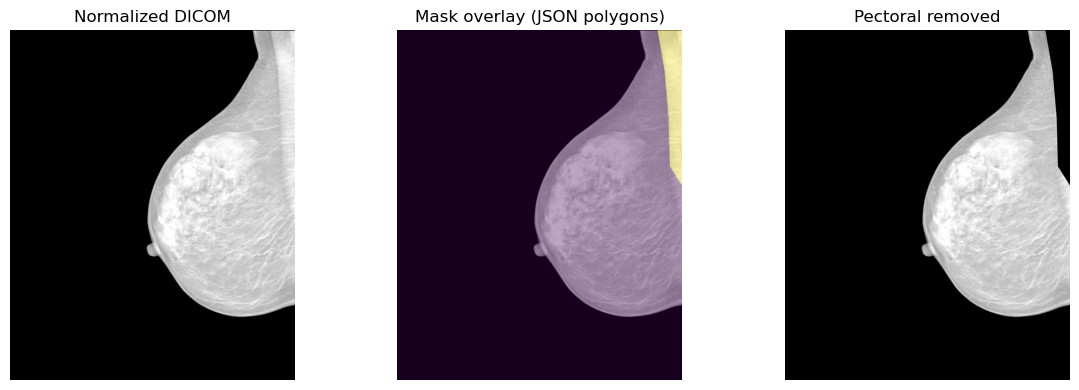

In [10]:
from pathlib import Path
import json
import random

import numpy as np
import pydicom
import matplotlib.pyplot as plt
import cv2
from pydicom.pixel_data_handlers.util import apply_voi_lut

# ---- EDIT THESE PATHS ----
DICOM_DIR = Path("data/raw/inbreast/ALL-IMGS")
MASK_DIR  = Path("data/raw/muscle_masks_for_raw_data")  # where you copied the JSON masks
# -------------------------

# 1) Collect files
dicoms = sorted(DICOM_DIR.glob("*.dcm"))

# ignore Windows "Zone.Identifier" garbage if present
json_masks = [p for p in MASK_DIR.rglob("*.json") if "Zone.Identifier" not in p.name]

print("DICOMs:", len(dicoms))
print("JSON masks:", len(json_masks))

mask_by_stem = {p.stem: p for p in json_masks}

matched = [p for p in dicoms if p.stem in mask_by_stem]
print("DICOMs with a matching JSON mask:", len(matched))

if len(matched) == 0:
    # helpful debugging: show example stems
    print("\nExample DICOM stems:", [p.stem for p in dicoms[:5]])
    print("Example MASK stems:", [p.stem for p in json_masks[:5]])
    raise RuntimeError("No matches found. Likely different naming scheme between your DICOMs and the mask JSONs.")

# 2) Helpers: load/normalize DICOM + convert LabelMe JSON polygons -> binary mask
def load_dicom_norm(path: Path) -> np.ndarray:
    ds = pydicom.dcmread(str(path))
    img = ds.pixel_array.astype(np.float32)

    try:
        img = apply_voi_lut(img, ds).astype(np.float32)
    except Exception:
        pass

    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = img.max() - img

    lo, hi = np.percentile(img, (1, 99))
    img = np.clip(img, lo, hi)
    img = (img - lo) / (hi - lo + 1e-8)
    return img

def labelme_json_to_mask(json_path: Path, shape_hw: tuple[int,int]) -> np.ndarray:
    """
    Makes a binary mask from LabelMe-like JSON.
    We fill ALL polygons found in 'shapes'.
    """
    H, W = shape_hw
    mask = np.zeros((H, W), dtype=np.uint8)

    with open(json_path, "r", encoding="utf-8") as f:
        ann = json.load(f)

    shapes = ann.get("shapes", [])
    for s in shapes:
        pts = np.array(s.get("points", []), dtype=np.float32)
        if pts.size == 0:
            continue
        pts = np.round(pts).astype(np.int32)
        pts[:, 0] = np.clip(pts[:, 0], 0, W - 1)
        pts[:, 1] = np.clip(pts[:, 1], 0, H - 1)
        cv2.fillPoly(mask, [pts], 1)

    return mask

# 3) Pick a random matched image (prefer MLO/ML if available)
def looks_like_mlo(name: str) -> bool:
    u = name.upper()
    return ("_MLO_" in u) or ("_ML_" in u)  # your masks use "_ML_" in the example

mlo_matched = [p for p in matched if looks_like_mlo(p.name)]
dicom_path = random.choice(mlo_matched if mlo_matched else matched)
mask_path = mask_by_stem[dicom_path.stem]

img = load_dicom_norm(dicom_path)
mask = labelme_json_to_mask(mask_path, img.shape)

# 4) Apply mask (remove pectoral)
img_no_pect = img.copy()
img_no_pect[mask == 1] = 0.0

print("\nExample:")
print("DICOM:", dicom_path.name)
print("MASK :", mask_path.name)
print("Image shape:", img.shape, "| Mask sum:", int(mask.sum()))

# 5) Show side-by-side
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("Normalized DICOM")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(img, cmap="gray")
plt.imshow(mask, alpha=0.35)
plt.title("Mask overlay (JSON polygons)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img_no_pect, cmap="gray")
plt.title("Pectoral removed")
plt.axis("off")

plt.tight_layout()
plt.show()

Cell 1 — Build mapping + dataset coverage report

In [12]:
from pathlib import Path
import re
import pandas as pd

DICOM_DIR = Path("data/raw/inbreast/ALL-IMGS")
MASK_DIR  = Path("data/raw/muscle_masks_for_raw_data")  # where your JSONs live

dicoms = sorted(DICOM_DIR.glob("*.dcm"))
json_masks = [p for p in MASK_DIR.rglob("*.json") if "Zone.Identifier" not in p.name]

print("DICOMs:", len(dicoms))
print("JSON masks:", len(json_masks))

mask_by_stem = {p.stem: p for p in json_masks}

rows = []
for d in dicoms:
    u = d.name.upper()
    view = "MLO" if "_MLO_" in u else ("CC" if "_CC_" in u else ("ML" if "_ML_" in u else "UNK"))
    lat  = "R" if "_R_" in u else ("L" if "_L_" in u else "UNK")
    rows.append({
        "stem": d.stem,
        "dicom": str(d),
        "view": view,
        "laterality": lat,
        "has_pect_json": d.stem in mask_by_stem,
        "pect_json": str(mask_by_stem[d.stem]) if d.stem in mask_by_stem else None,
    })

cov = pd.DataFrame(rows)
display(cov["has_pect_json"].value_counts())
display(cov.groupby(["view","has_pect_json"]).size().unstack(fill_value=0))

DICOMs: 410
JSON masks: 202


has_pect_json
False    208
True     202
Name: count, dtype: int64

has_pect_json,False,True
view,,
CC,202,1
ML,5,201
UNK,1,0


Cell 2 — Core helpers (DICOM normalize + JSON polygons → mask)

In [13]:
import json
import numpy as np
import pydicom
import matplotlib.pyplot as plt
import cv2
from pydicom.pixel_data_handlers.util import apply_voi_lut

def load_dicom_norm(path: Path) -> np.ndarray:
    ds = pydicom.dcmread(str(path))
    img = ds.pixel_array.astype(np.float32)

    try:
        img = apply_voi_lut(img, ds).astype(np.float32)
    except Exception:
        pass

    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = img.max() - img

    lo, hi = np.percentile(img, (1, 99))
    img = np.clip(img, lo, hi)
    img = (img - lo) / (hi - lo + 1e-8)
    return img

def labelme_json_to_mask(json_path: Path, shape_hw: tuple[int,int]) -> np.ndarray:
    """Fill all polygons in LabelMe-style JSON into a binary mask."""
    H, W = shape_hw
    mask = np.zeros((H, W), dtype=np.uint8)

    with open(json_path, "r", encoding="utf-8") as f:
        ann = json.load(f)

    shapes = ann.get("shapes", [])
    for s in shapes:
        pts = np.array(s.get("points", []), dtype=np.float32)
        if pts.size == 0:
            continue
        pts = np.round(pts).astype(np.int32)
        pts[:, 0] = np.clip(pts[:, 0], 0, W - 1)
        pts[:, 1] = np.clip(pts[:, 1], 0, H - 1)
        cv2.fillPoly(mask, [pts], 1)

    return mask

Cell 3 — Breast mask + CLAHE + preprocess_one

In [14]:
from scipy import ndimage as ndi

def to_uint8(img01: np.ndarray) -> np.ndarray:
    return (np.clip(img01, 0, 1) * 255).astype(np.uint8)

def make_breast_mask(img01: np.ndarray) -> np.ndarray:
    """
    Segment breast vs background:
    - Otsu threshold on normalized image
    - morphology cleanup
    - keep largest component
    - fill holes
    """
    u8 = to_uint8(img01)
    _, m = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k, iterations=2)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k, iterations=1)

    num, labels = cv2.connectedComponents(m)
    if num <= 1:
        mask = (m > 0).astype(np.uint8)
    else:
        sizes = [(labels == i).sum() for i in range(1, num)]
        biggest = 1 + int(np.argmax(sizes))
        mask = (labels == biggest).astype(np.uint8)

    mask = ndi.binary_fill_holes(mask).astype(np.uint8)
    return mask

def apply_clahe(img01: np.ndarray, mask: np.ndarray, clip=2.0, tiles=(8,8)) -> np.ndarray:
    u8 = to_uint8(img01)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=tiles)
    enh = clahe.apply(u8).astype(np.float32) / 255.0
    return enh * mask.astype(np.float32)

def preprocess_one(dicom_path: Path, do_contrast=True):
    """
    Returns a dict of intermediate + final images/masks (all numpy arrays).
    """
    norm = load_dicom_norm(dicom_path)

    # Pectoral removal ONLY if we have a matching JSON (and only for oblique-ish views)
    u = dicom_path.name.upper()
    is_oblique = ("_MLO_" in u) or ("_ML_" in u)

    pect_mask = np.zeros_like(norm, dtype=np.uint8)
    if is_oblique and dicom_path.stem in mask_by_stem:
        pect_mask = labelme_json_to_mask(mask_by_stem[dicom_path.stem], norm.shape)

    no_pect = norm.copy()
    no_pect[pect_mask == 1] = 0.0

    # Breast mask after pectoral removal (usually cleaner)
    breast_mask = make_breast_mask(no_pect)

    bg_removed = no_pect * breast_mask.astype(np.float32)

    final = apply_clahe(bg_removed, breast_mask) if do_contrast else bg_removed

    return {
        "norm": norm,
        "pect_mask": pect_mask,
        "no_pect": no_pect,
        "breast_mask": breast_mask,
        "bg_removed": bg_removed,
        "final": final,
    }

Cell 4 — Single-image “coworker-style” plot (sanity check)

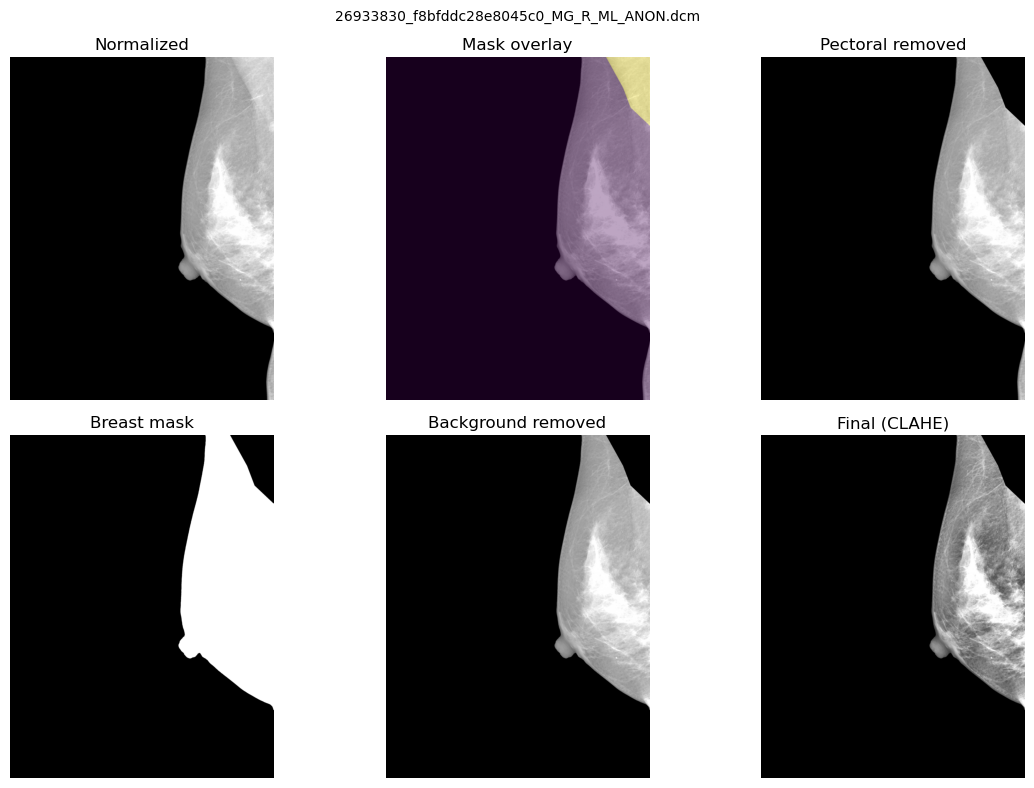

In [15]:
import random
import matplotlib.pyplot as plt

mlo_like = [Path(r["dicom"]) for r in rows if r["view"] in ("MLO","ML")]
p = random.choice(mlo_like if mlo_like else dicoms)

out = preprocess_one(p, do_contrast=True)

plt.figure(figsize=(12,8))
plt.subplot(2,3,1); plt.imshow(out["norm"], cmap="gray"); plt.title("Normalized"); plt.axis("off")
plt.subplot(2,3,2); plt.imshow(out["norm"], cmap="gray"); plt.imshow(out["pect_mask"], alpha=0.35); plt.title("Mask overlay"); plt.axis("off")
plt.subplot(2,3,3); plt.imshow(out["no_pect"], cmap="gray"); plt.title("Pectoral removed"); plt.axis("off")
plt.subplot(2,3,4); plt.imshow(out["breast_mask"], cmap="gray"); plt.title("Breast mask"); plt.axis("off")
plt.subplot(2,3,5); plt.imshow(out["bg_removed"], cmap="gray"); plt.title("Background removed"); plt.axis("off")
plt.subplot(2,3,6); plt.imshow(out["final"], cmap="gray"); plt.title("Final (CLAHE)"); plt.axis("off")
plt.suptitle(p.name, fontsize=10)
plt.tight_layout()
plt.show()

Cell 5 — Batch preprocess + save (fast + reusable for training)

In [16]:
import os
from tqdm import tqdm
import pandas as pd
import numpy as np

OUT_DIR = Path("data/processed/preproc_v1")
(OUT_DIR / "final").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "breast_mask").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "pect_mask").mkdir(parents=True, exist_ok=True)

index_rows = []

for d in tqdm(dicoms, total=len(dicoms)):
    o = preprocess_one(d, do_contrast=True)

    stem = d.stem
    final_path = OUT_DIR / "final" / f"{stem}.npy"
    bmask_path = OUT_DIR / "breast_mask" / f"{stem}.npy"
    pmask_path = OUT_DIR / "pect_mask" / f"{stem}.npy"

    np.save(final_path, o["final"].astype(np.float32))
    np.save(bmask_path, o["breast_mask"].astype(np.uint8))
    np.save(pmask_path, o["pect_mask"].astype(np.uint8))

    u = d.name.upper()
    view = "MLO" if "_MLO_" in u else ("CC" if "_CC_" in u else ("ML" if "_ML_" in u else "UNK"))
    lat  = "R" if "_R_" in u else ("L" if "_L_" in u else "UNK")

    index_rows.append({
        "stem": stem,
        "dicom": str(d),
        "final_npy": str(final_path),
        "breast_mask_npy": str(bmask_path),
        "pect_mask_npy": str(pmask_path),
        "view": view,
        "laterality": lat,
        "has_pect_json": int(o["pect_mask"].sum() > 0),
        "pect_json": str(mask_by_stem[stem]) if stem in mask_by_stem else None,
    })

index_df = pd.DataFrame(index_rows)
index_csv = OUT_DIR / "preproc_index.csv"
index_df.to_csv(index_csv, index=False)
print("Saved:", index_csv)
display(index_df.head())

100%|██████████| 410/410 [30:49<00:00,  4.51s/it]

Saved: data\processed\preproc_v1\preproc_index.csv


,stem,dicom,final_npy,breast_mask_npy,pect_mask_npy,view,laterality,has_pect_json,pect_json
0,20586908_6c613a14b80a8591_MG_R_CC_ANON,data\raw\inbreast\ALL-IMGS\20586908_6c613a14b8...,data\processed\preproc_v1\final\20586908_6c613...,data\processed\preproc_v1\breast_mask\20586908...,data\processed\preproc_v1\pect_mask\20586908_6...,CC,R,0,None
1,20586934_6c613a14b80a8591_MG_L_CC_ANON,data\raw\inbreast\ALL-IMGS\20586934_6c613a14b8...,data\processed\preproc_v1\final\20586934_6c613...,data\processed\preproc_v1\breast_mask\20586934...,data\processed\preproc_v1\pect_mask\20586934_6...,CC,L,0,None
2,20586960_6c613a14b80a8591_MG_R_ML_ANON,data\raw\inbreast\ALL-IMGS\20586960_6c613a14b8...,data\processed\preproc_v1\final\20586960_6c613...,data\processed\preproc_v1\breast_mask\20586960...,data\processed\preproc_v1\pect_mask\20586960_6...,ML,R,1,data\raw\muscle_masks_for_raw_data\20586960_6c...
3,20586986_6c613a14b80a8591_MG_L_ML_ANON,data\raw\inbreast\ALL-IMGS\20586986_6c613a14b8...,data\processed\preproc_v1\final\20586986_6c613...,data\processed\preproc_v1\breast_mask\20586986...,data\processed\preproc_v1\pect_mask\20586986_6...,ML,L,1,data\raw\muscle_masks_for_raw_data\20586986_6c...
4,20587054_b6a4f750c6df4f90_MG_R_CC_ANON,data\raw\inbreast\ALL-IMGS\20587054_b6a4f750c6...,data\processed\preproc_v1\final\20587054_b6a4f...,data\processed\preproc_v1\breast_mask\20587054...,data\processed\preproc_v1\pect_mask\20587054_b...,CC,R,0,None


stem: 22580244_5530d5782fc89dd7_MG_R_ML_ANON
final: float32 (3328, 2560) min=0.0000 max=1.0000 mean=0.2651
breast_mask: uint8 (3328, 2560) sum: 3520812 frac: 0.4132563664362981
pect_mask: uint8 (3328, 2560) sum: 444249 frac: 0.05214385986328125


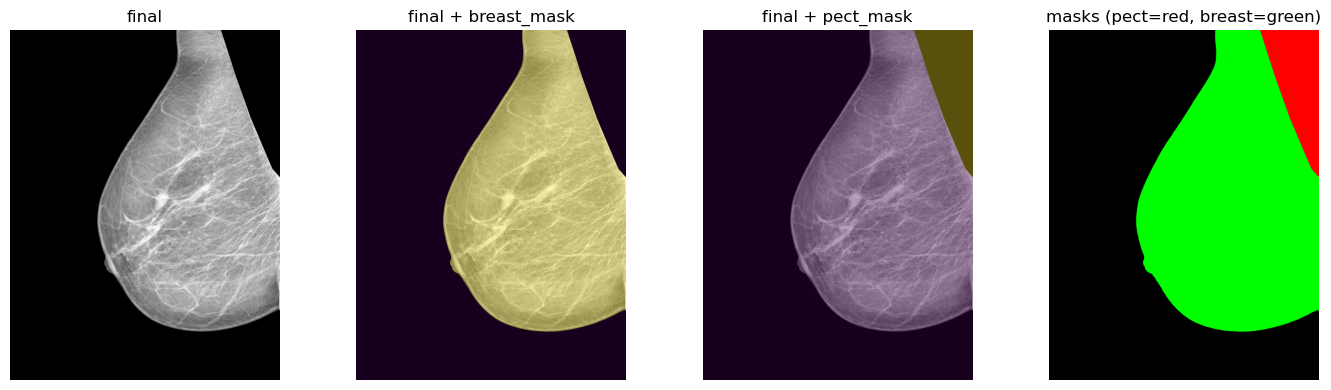

stem: 22670511_7e677f3d530e41ed_MG_L_ML_ANON
final: float32 (3328, 2560) min=0.0000 max=1.0000 mean=0.1984
breast_mask: uint8 (3328, 2560) sum: 2771900 frac: 0.3253525954026442
pect_mask: uint8 (3328, 2560) sum: 623067 frac: 0.07313267634465144


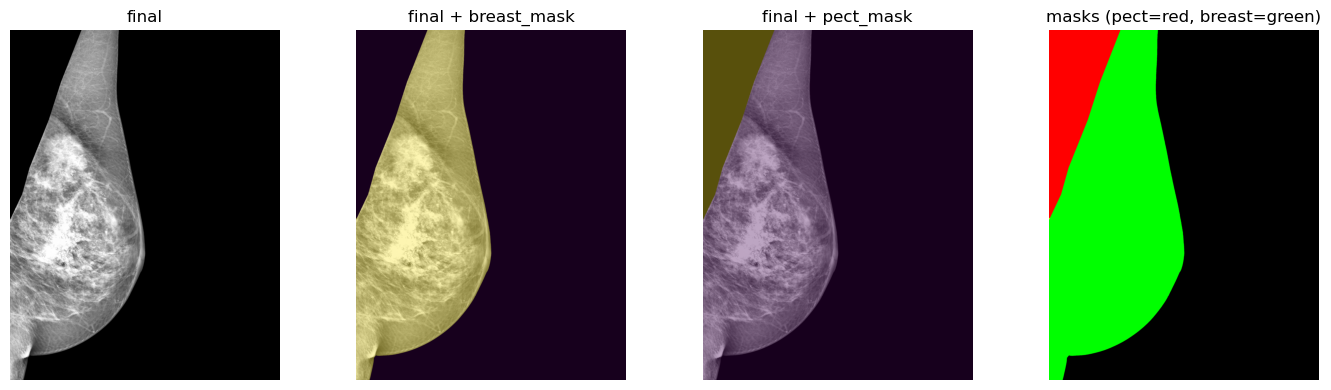

stem: 50993697_b03f1dd34eb3c55f_MG_L_CC_ANON
final: float32 (4084, 3328) min=0.0000 max=1.0000 mean=0.1339
breast_mask: uint8 (4084, 3328) sum: 2820644 frac: 0.2075292063776087
pect_mask: uint8 (4084, 3328) sum: 0 frac: 0.0


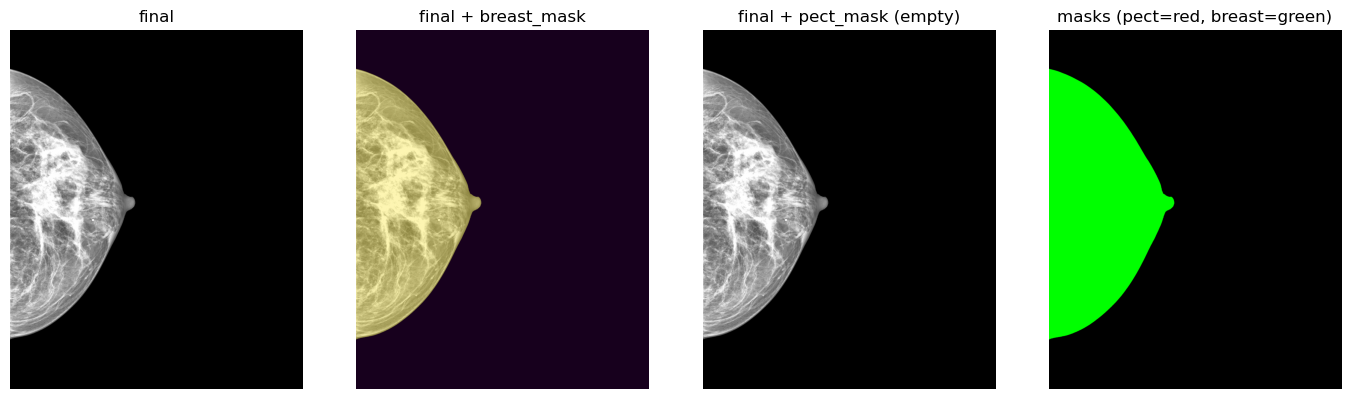

stem: 22670832_0b7396cdccacca82_MG_L_CC_ANON
final: float32 (4084, 3328) min=0.0000 max=0.9961 mean=0.1956
breast_mask: uint8 (4084, 3328) sum: 3329913 frac: 0.24499873156501922
pect_mask: uint8 (4084, 3328) sum: 0 frac: 0.0


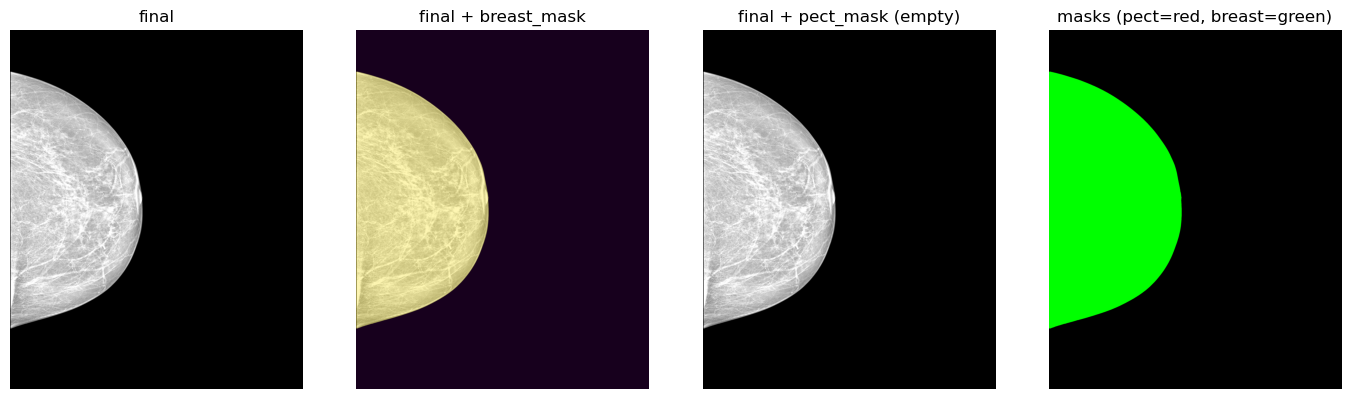

stem: 53581433_b231a8ba4dd4214f_MG_L_CC_ANON
final: float32 (3328, 2560) min=0.0000 max=1.0000 mean=0.2441
breast_mask: uint8 (3328, 2560) sum: 2885814 frac: 0.33872328538161056
pect_mask: uint8 (3328, 2560) sum: 0 frac: 0.0


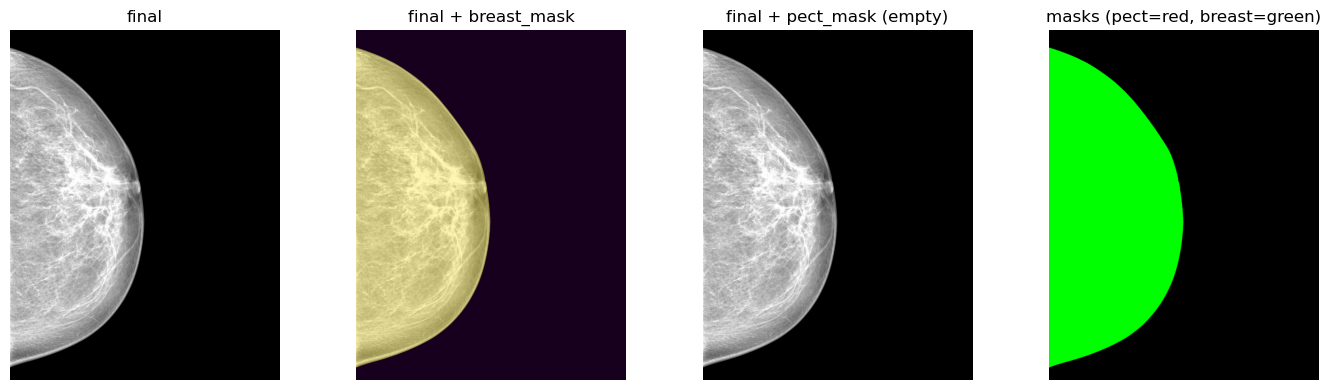

In [18]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = Path("data/processed/preproc_v1")  # change if needed

final_dir = OUT_DIR / "final"
bmask_dir = OUT_DIR / "breast_mask"
pmask_dir = OUT_DIR / "pect_mask"

final_files = sorted(final_dir.glob("*.npy"))
assert final_files, f"No .npy files found in {final_dir.resolve()}"

k = min(5, len(final_files))
samples = random.sample(final_files, k=k)

for p in samples:
    stem = p.stem

    final = np.load(final_dir / f"{stem}.npy")
    bmask = np.load(bmask_dir / f"{stem}.npy")
    pmask = np.load(pmask_dir / f"{stem}.npy")

    print("=" * 60)
    print("stem:", stem)
    print("final:", final.dtype, final.shape, f"min={final.min():.4f}", f"max={final.max():.4f}", f"mean={final.mean():.4f}")
    print("breast_mask:", bmask.dtype, bmask.shape, "sum:", int(bmask.sum()), "frac:", float(bmask.mean()))
    print("pect_mask:", pmask.dtype, pmask.shape, "sum:", int(pmask.sum()), "frac:", float(pmask.mean()))

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(final, cmap="gray")
    plt.title("final")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(final, cmap="gray")
    plt.imshow(bmask, alpha=0.35)
    plt.title("final + breast_mask")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(final, cmap="gray")
    if pmask.sum() > 0:
        plt.imshow(pmask, alpha=0.35)
        plt.title("final + pect_mask")
    else:
        plt.title("final + pect_mask (empty)")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    # show just the masks side-by-side via RGB composite (breast=green, pect=red)
    comp = np.zeros((*final.shape, 3), dtype=np.float32)
    comp[..., 1] = bmask.astype(np.float32)  # green
    comp[..., 0] = pmask.astype(np.float32)  # red
    plt.imshow(comp)
    plt.title("masks (pect=red, breast=green)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

DICOM: 20587810_81cd83d2f4d78528_MG_L_ML_ANON.dcm
JSON : 20587810_81cd83d2f4d78528_MG_L_ML_ANON.json


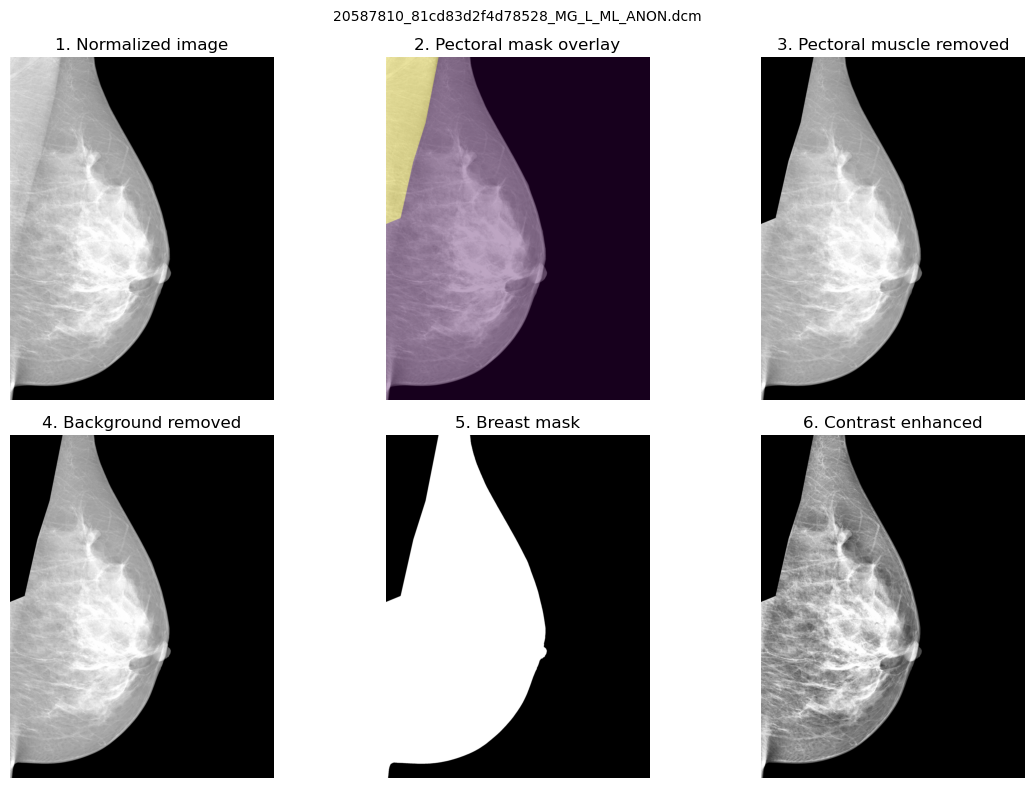

Stats: | pectoral pixels: 522956 | breast pixels: 3407728 | final range: 0.0 to 1.0


In [22]:
# Single-cell "coworker-style" sanity plot for a specific case ID (e.g. 20587810)
# Shows: Normalized -> Pectoral mask overlay -> Pectoral removed -> Background removed -> Breast mask -> Contrast enhanced

from pathlib import Path
import json
import numpy as np
import pydicom
import matplotlib.pyplot as plt
import cv2
from scipy import ndimage as ndi
from pydicom.pixel_data_handlers.util import apply_voi_lut

# -------------------------
# EDIT PATHS
DICOM_DIR = Path("data/raw/inbreast/ALL-IMGS")
MASK_DIR  = Path("data/raw/muscle_masks_for_raw_data")   # folder containing *.json polygon masks
CASE_ID   = "20587810"                            # <-- your example
# -------------------------

def load_dicom_norm(path: Path) -> np.ndarray:
    ds = pydicom.dcmread(str(path))
    img = ds.pixel_array.astype(np.float32)

    try:
        img = apply_voi_lut(img, ds).astype(np.float32)
    except Exception:
        pass

    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = img.max() - img

    lo, hi = np.percentile(img, (1, 99))
    img = np.clip(img, lo, hi)
    img = (img - lo) / (hi - lo + 1e-8)
    return img

def labelme_json_to_mask(json_path: Path, shape_hw: tuple[int, int]) -> np.ndarray:
    H, W = shape_hw
    mask = np.zeros((H, W), dtype=np.uint8)

    with open(json_path, "r", encoding="utf-8") as f:
        ann = json.load(f)

    shapes = ann.get("shapes", [])
    for s in shapes:
        pts = np.array(s.get("points", []), dtype=np.float32)
        if pts.size == 0:
            continue
        pts = np.round(pts).astype(np.int32)
        pts[:, 0] = np.clip(pts[:, 0], 0, W - 1)
        pts[:, 1] = np.clip(pts[:, 1], 0, H - 1)
        cv2.fillPoly(mask, [pts], 1)

    # small cleanup (optional)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=1)

    return mask

def to_uint8(img01: np.ndarray) -> np.ndarray:
    return (np.clip(img01, 0, 1) * 255).astype(np.uint8)

def make_breast_mask(img01: np.ndarray) -> np.ndarray:
    u8 = to_uint8(img01)
    _, m = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k, iterations=2)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k, iterations=1)

    num, labels = cv2.connectedComponents(m)
    if num <= 1:
        mask = (m > 0).astype(np.uint8)
    else:
        sizes = [(labels == i).sum() for i in range(1, num)]
        biggest = 1 + int(np.argmax(sizes))
        mask = (labels == biggest).astype(np.uint8)

    mask = ndi.binary_fill_holes(mask).astype(np.uint8)
    return mask

def apply_clahe(img01: np.ndarray, mask: np.ndarray, clip=2.0, tiles=(8, 8)) -> np.ndarray:
    u8 = to_uint8(img01)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=tiles)
    enh = clahe.apply(u8).astype(np.float32) / 255.0
    return enh * mask.astype(np.float32)

# ---------- locate matching DICOM and JSON ----------
dicom_matches = sorted(DICOM_DIR.glob(f"{CASE_ID}*.dcm"))
assert dicom_matches, f"No DICOM found starting with {CASE_ID} in {DICOM_DIR.resolve()}"

# Prefer ML/MLO if multiple
def is_oblique(name: str) -> bool:
    u = name.upper()
    return ("_ML_" in u) or ("_MLO_" in u)

dicom_path = None
for p in dicom_matches:
    if is_oblique(p.name):
        dicom_path = p
        break
dicom_path = dicom_path or dicom_matches[0]

json_matches = [p for p in MASK_DIR.rglob(f"{dicom_path.stem}.json") if "Zone.Identifier" not in p.name]
json_path = json_matches[0] if json_matches else None

print("DICOM:", dicom_path.name)
print("JSON :", None if json_path is None else json_path.name)

# ---------- run preprocessing ----------
norm = load_dicom_norm(dicom_path)

pect_mask = np.zeros_like(norm, dtype=np.uint8)
no_pect = norm.copy()
if json_path is not None and json_path.exists():
    pect_mask = labelme_json_to_mask(json_path, norm.shape)
    no_pect[pect_mask == 1] = 0.0

breast_mask = make_breast_mask(no_pect)
bg_removed = no_pect * breast_mask.astype(np.float32)
contrast = apply_clahe(bg_removed, breast_mask, clip=2.0, tiles=(8, 8))

# ---------- plot ----------
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(norm, cmap="gray")
plt.title("1. Normalized image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(norm, cmap="gray")
plt.imshow(pect_mask, alpha=0.35)
plt.title("2. Pectoral mask overlay")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(no_pect, cmap="gray")
plt.title("3. Pectoral muscle removed")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(bg_removed, cmap="gray")
plt.title("4. Background removed")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(breast_mask, cmap="gray")
plt.title("5. Breast mask")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(contrast, cmap="gray")
plt.title("6. Contrast enhanced")
plt.axis("off")

plt.suptitle(f"{dicom_path.name}", fontsize=10)
plt.tight_layout()
plt.show()

print("Stats:",
      "| pectoral pixels:", int(pect_mask.sum()),
      "| breast pixels:", int(breast_mask.sum()),
      "| final range:", float(contrast.min()), "to", float(contrast.max()))